# COLAB 3: The Cloud-to-Edge Brain-Machine Interface

## Course architecture

Input design ➡️ On-device input processor ➡️ On-device output processor ➡️ Resource usage logger

**Platform Context:** MicroPython Runtime Architecture Layer (Simulated/Physical Target Host)  
**Motivating Domain:** Real-Time Embedded Neuroprosthetics & Wearable Edge Medical Devices  
**Target Open Dataset:** Live 100 Hz Streaming Packets

## Instructions for the student
You have successfully automated your pipeline and scaled it across multi-core cloud environments. Now comes the final deployment stage: moving your scientific insight directly onto a mobile edge device ([the BBC micro:bit V2 microcontroller](https://microbit.org)).

Microcontrollers are resource-constrained environments. A micro:bit V2 features only **128 KB of volatile RAM** and does not possess heavy scientific computing frameworks like `numpy` or `scipy`. Processing high-dimensional data arrays directly on this chip will cause immediate system memory exhaustion.

Your objective is to use the embedded **"AI Edge Challenges"** to prompt your AI assistant to build
1. a micro:bit-compatible input stream,
2. an on-device input processing program,
3. a resource usage logger.

While we encourage you to play around with the official [micro:bit simulator](https://makecode.microbit.org/#editor), for simplicity, we will simulate micro:bit's environment using the Python class below. You will implement its functionality step-by-step using AI prompting.

In [ ]:
import numpy as np
import time
from datetime import datetime
from IPython.display import clear_output

class MicroBit:

    def __init__(self):
        super().__init__()

        self.MAX_RAM = 128 * 1024 # (bytes)
        self.MAX_STORAGE = 512 * 1024 # (bytes)

        self.buffer = []
        self.storage = []

    def ram_used(self):
        return np.array(self.buffer).nbytes

    def _is_ram_available(self):
        if self.ram_used() <= self.MAX_RAM:
            return True
        return False
    
    def output_to_screen(self, positions):
        clear_output(wait = True)
        grid = np.full((5, 5), '.', dtype=str)

        for r, c in positions:
            grid[r, c] = '*'

        for row in grid:
            print(' '.join(row))
    
    def read_from_temperature_sensor(self, input_stream):
        # TODO: Implement using AI prompting
        pass
    
    def process_temperature_data(self):
        # TODO: Implement using AI prompting
        pass

    def to_file(self, file):
        # TODO: Implement using AI prompting
        pass

## Module 1: Input design

### Mechanics

We will model input from the temperature sensor embedded into each micro:bit. On a real device, data arrives timestamp-by-timestamp as tiny voltage pulses sent over serial connections. Here we instantiate such a continuous signal loop, assuming it was received and is being stored in a buffer.

### Student AI prompt challenge

Copy and paste this text block into your AI assistant:

> Write a python function generate_temperature_signal() that takes the input sampling rate in Hz, the length of the signal in ms, and a random seed (default = 123) and generates a 1d numpy array with temperature readings in celcius. Each temperature value should be randomly sampled from a 20-to-30-degrees interval. Each temperature reading is a sum of the actual temperature value and device-specific noise (normal with small SD). Use np.random.RandomState as RNG.

In [ ]:
# TODO: Your code here

Now we can generate a 5-second signal sampled at 100 Hz using 123 as a random seed and visualize the signal.

In [ ]:
signal = generate_temperature_signal(sampling_rate_hz = 1000, length_ms = 5000, random_seed = 123)

Text(0, 0.5, 'Temperature (deg C)')

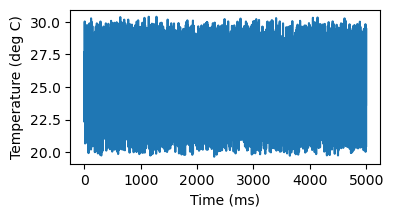

In [43]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize = (4, 2))

ax.plot(signal)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Temperature (deg C)")

## Module 2: On-device input processor

### Student AI prompt challenge

Copy and paste the `MicroBit` class below and this text block into your AI assistant:
> Write the function read_from_temperature_sensor assuming input_stream is a 1d numpy array. The function should read the array element-by-element, check if RAM is available, and if so, save the value into the buffer. It should print "[ERROR]: Out of RAM!" if no more RAM is available and return 1. If it managed to successfully read the whole stream, it should print f"[SUCCESS] Used RAM: {self.ram_used()} bytes." and return 0.

Modify the class above and run the cell below.

In [77]:
microbit = MicroBit()
microbit.read_from_temperature_sensor(signal)

[SUCCESS] Used RAM: 40000 bytes.


0

## Module 3: On-device output processor

### Student AI prompt challenge
Copy and paste the `MicroBit` class and this text block into your AI assistant:
> Now write the function process_temperature_data. It should read from the buffer value-by-value and if the value > 25, output to screen at position (2, 2), else output to screen at position (0, 0).

Modify the class above and run the cell below.

In [ ]:
microbit.process_temperature_data()

## Module 4: Resource usage logger

### Student AI prompt challenge
Copy and paste the `MicroBit` class and this text block into your AI assistant:
> Now write the function to_file which takes the file name and appends the current time (datetime.now().time()) and the current RAM used. If the file does not exist, the function should automatically create it.

Modify the class above and run the cell below.

In [ ]:
microbit.to_file("out.txt")

## Embedded playground

**Task 1.** Generate input that will make micro:bit run out of RAM.

**Task 2.** Modify the `read_from_temperature_sensor()` function to output used RAM while continuously reading input.

**Task 3.** Modify the `process_temperature_data()` function to display the first digit of the temperature.

**Task 4.** Prompt AI to make it possible to store sensor data in the micro:bit's internal storage. 

In [81]:
microbit = MicroBit()
signal = generate_temperature_signal(sampling_rate_hz = 10, length_ms = 1000, random_seed = 123)

microbit.read_from_temperature_sensor(signal)
microbit.process_temperature_data()

* . . . .
. . . . .
. . . . .
. . . . .
. . . . .
